# 학습 - 확률적 경사 하강법
- 신경망의 가중치/편향을 훈련데이터에 맞게 조정
1. 미니배치 - 훈련 데이터 무작위 일부 선정
2. 기울기 계산 
    - 각 가중치 매개변수의 기울기 계산
    - 손실함수의 값을 가장 줄이는 방향 제시
3. 가중치 업데이트 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from b1.func import sigmoid, softmax, cee
from b1.func import num_grad as _num_grad

## 단순 수치 미분 구현

In [18]:
class TLNet:
    def __init__(self, input_dim, hidden_dim, output_dim, weight_init_std=0.01):
        self.params = {}
        self.params["W1"] = weight_init_std * np.random.randn(input_dim, hidden_dim)
        self.params["b1"] = np.zeros(hidden_dim)
        self.params["W2"] = weight_init_std * np.random.randn(hidden_dim, output_dim)
        self.params["b2"] = np.zeros(output_dim)

    def forward(self, x):
        W1, W2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]

        z = np.dot(x, W1) + b1
        a = sigmoid(z)
        z = np.dot(a, W2) + b2
        y = softmax(z)

        return y

    def loss(self, x, t):
        y = self.forward(x)
        return cee(y, t)

    def acc(self, x, t):
        y = self.forward(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def num_grad(self, x, t):
        loss_W = lambda W: self.loss(x, t)  #noqa E731

        grads = {}
        grads["W1"] = _num_grad(loss_W, self.params["W1"])
        grads["b1"] = _num_grad(loss_W, self.params["b1"])
        grads["W2"] = _num_grad(loss_W, self.params["W2"])
        grads["b2"] = _num_grad(loss_W, self.params["b2"])

        return grads

In [ ]:
# 수치미분까지 전체 연습용
class _TLNet:
    def __init__(self, input_dim, hidden_dim, output_dim, init_std=0.01):
        self.params = {}
        self.params["W1"] = init_std * np.random.randn(input_dim, hidden_dim)
        self.params["W2"] = init_std * np.random.randn(hidden_dim, output_dim)
        self.params["b1"] = np.random.randn(hidden_dim)
        self.params["b2"] = np.random.randn(output_dim)

    @staticmethod
    def _sigmoid(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def _softmax(x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)

    @staticmethod
    def _cee(y:np.ndarray, t:np.ndarray):
        if y.ndim == 1:
            y = y.reshape(1, y.size)
            t = t.reshape(1, t.size)

        return -np.sum(t * np.log(y + 1e-7)) / y.shape[0]

    @staticmethod
    def _num_grad(f, x, h=1e-4):
        grad = np.zeros_like(x)
        it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])

        while not it.finished:
            idx = it.multi_index
            tmp_val = x[idx]

            x[idx] = tmp_val + h
            fxph = f(x)

            x[idx] = tmp_val - h
            fxmh = f(x)

            grad[idx] = (fxph + fxmh) / (2 * h)
            x[idx] = tmp_val
            it.iternext()

        return grad

    def forward(self, x):
        w1, w2 = self.params["W1"], self.params["W2"]
        b1, b2 = self.params["b1"], self.params["b2"]

        x = x @ w1 + b1
        x = self._sigmoid(x)
        x = x @ w2 + b2
        x = self._softmax(x)
        return x

    def loss(self, x, t):
        y = self.forward(x)
        return self._cee(y, t)

    def acc(self, x, t):
        y = np.argmax(self.forward(x))
        t = np.argmax(t)

        return np.sum(y == t) / x.shape[0]

    def num_grad(self, x, t):
        loss_W = lambda w: self.loss(x, t)

        grads = {}
        grads["W1"] = self._num_grad(loss_W, self.params["W1"])
        grads["W2"] = self._num_grad(loss_W, self.params["W2"])
        grads["b1"] = self._num_grad(loss_W, self.params["b1"])
        grads["b2"] = self._num_grad(loss_W, self.params["b1"])

        return grads


## 역전파 구현

In [279]:
from collections import OrderedDict
from b1.module import Relu, Sigmoid, Affine, SoftmaxWithLoss


class BTLNet:
    def __init__(self, input_dim, hidden_dim, output_dim, weight_init_std=0.01):
        self.params = {}
        self.params["W1"] = weight_init_std * np.random.randn(input_dim, hidden_dim)
        self.params["b1"] = np.zeros(hidden_dim)
        self.params["W2"] = weight_init_std * np.random.randn(hidden_dim, output_dim)
        self.params["b2"] = np.zeros(output_dim)

        self.layers = OrderedDict()
        self.layers["Affine1"] = Affine(self.params["W1"], self.params["b1"])
        self.layers["Relu1"] = Relu()
        self.layers["Affine2"] = Affine(self.params["W2"], self.params["b2"])

        self.last_layer = SoftmaxWithLoss()

    def forward(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.forward(x)
        return self.last_layer.forward(y, t)

    def acc(self, x, t):
        y = self.forward(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def num_grad(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads["W1"] = _num_grad(loss_W, self.params["W1"])
        grads["b1"] = _num_grad(loss_W, self.params["b1"])
        grads["W2"] = _num_grad(loss_W, self.params["W2"])
        grads["b2"] = _num_grad(loss_W, self.params["b2"])

        return grads

    def grad(self, x, t):
        self.loss(x, t)

        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads["W1"], grads["b1"] = self.layers["Affine1"].dW, self.layers["Affine1"].db
        grads["W2"], grads["b2"] = self.layers["Affine2"].dW, self.layers["Affine2"].db

        return grads

In [20]:
def shape_param_dict(x):
    return {k:v.shape for k, v in x.items()}

### 수치미분과 역전파 차이
- 파라미터 개수 P, 순전파 연산량 C
- 수치 미분
    - 파라미터 하나당 순전파 2회 - 중심차분
    - $O(PC)$ 
- 역전파
    - 파라미터 전체에 대해 순전파 1회
    - $O(C)$
- 수치미분은 역전파보다 파라미터 수만큼 비효율적 - 현재 예시에서는 대략 100,000배

In [33]:
x = np.random.randn(10, 784)
t = np.random.randn(10, 10)

In [34]:
%%time
net = TLNet(784, 100, 10)
print(f"forward: {net.forward(x).shape}")
print(f"loss:    {net.loss(x, t)}")
print(f"acc:     {net.acc(x, t)}")
print(f"grad:    {shape_param_dict(net.num_grad(x, t))}")

forward: (10, 10)
loss:    -4.740639299681305
acc:     0.1
grad:    {'W1': (784, 100), 'b1': (100,), 'W2': (100, 10), 'b2': (10,)}
CPU times: user 21.8 s, sys: 16.7 ms, total: 21.9 s
Wall time: 10.9 s


In [35]:
%%time
net = BTLNet(784, 100, 10)
print(f"forward: {net.forward(x).shape}")
print(f"loss:    {net.loss(x, t)}")
print(f"acc:     {net.acc(x, t)}")
print(f"grad:    {shape_param_dict(net.grad(x, t))}")

forward: (10, 10)
loss:    -4.826095435155115
acc:     0.1
grad:    {'W1': (784, 100), 'b1': (100,), 'W2': (100, 10), 'b2': (10,)}
CPU times: user 2.7 ms, sys: 12 μs, total: 2.71 ms
Wall time: 2.33 ms


## mnist 학습

In [262]:
from datasets.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(one_hot_label=True)

In [270]:
n_iter = 10000
batch_size = 100
lr = 0.1

train_size = x_train.shape[0]
iter_per_epoch = max(train_size / batch_size, 1)

In [289]:
net = BTLNet(784, 50, 10)

train_losses = []
train_accs = []
test_accs = []

for i in tqdm(range(n_iter)):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grad = net.grad(x_batch, t_batch)

    for k in net.params.keys():
        net.params[k] -= lr * grad[k]


    loss = net.loss(x_batch, t_batch)
    train_losses.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = net.acc(x_train, t_train)
        test_acc = net.acc(x_test, t_test)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"train acc: {train_acc}, test acc: {test_acc}")

  0%|          | 8/10000 [00:00<06:32, 25.49it/s]

train acc: 0.1277, test acc: 0.1247


  6%|▌         | 618/10000 [00:01<00:25, 362.29it/s]

train acc: 0.8972333333333333, test acc: 0.9046


 13%|█▎        | 1290/10000 [00:03<00:19, 452.42it/s]

...

 91%|█████████ | 9098/10000 [00:20<00:03, 226.29it/s]

train acc: 0.97825, test acc: 0.9663


 98%|█████████▊| 9774/10000 [00:21<00:00, 543.49it/s]

train acc: 0.9784166666666667, test acc: 0.9668


100%|██████████| 10000/10000 [00:21<00:00, 455.49it/s]


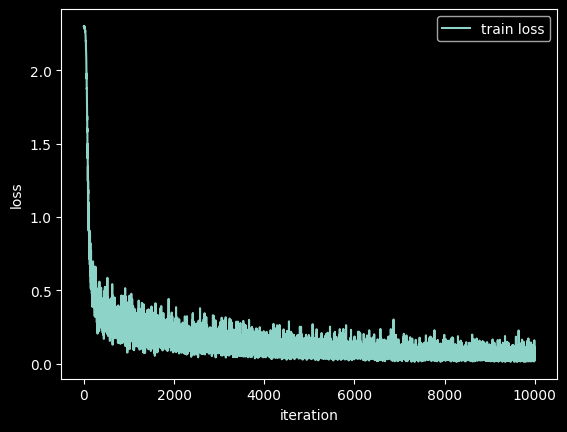

In [290]:
plt.plot(train_losses, label="train loss")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

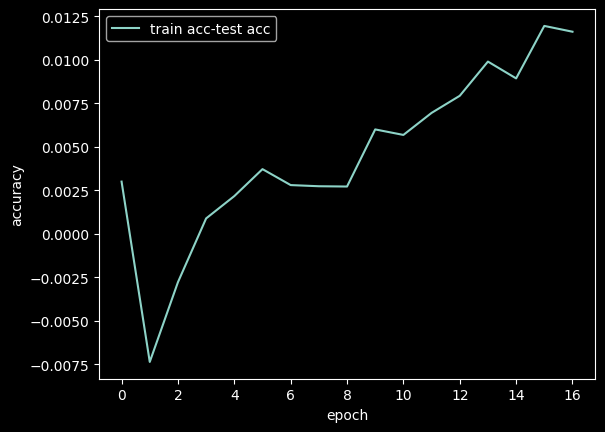

In [296]:
plt.plot((np.array(train_accs) - np.array(test_accs)), label="train acc-test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [ ]:
net = BTLNet(784, 50, 10)

train_losses = []
train_accs = []
test_accs = []

for i in tqdm(range(n_iter // batch_size)):


    grad = net.grad(x_train, t_train)

    for k in net.params.keys():
        net.params[k] -= lr * grad[k]


    loss = net.loss(x_train, t_train)
    train_losses.append(loss)

    if i % 10 == 0:
        train_acc = net.acc(x_train, t_train)
        test_acc = net.acc(x_test, t_test)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"train acc: {train_acc}, test acc: {test_acc}")

  1%|          | 1/100 [00:00<01:35,  1.04it/s]

train acc: 0.11045, test acc: 0.1046


 11%|█         | 11/100 [00:07<01:04,  1.38it/s]

train acc: 0.43198333333333333, test acc: 0.4396


 21%|██        | 21/100 [00:16<01:11,  1.11it/s]

...

 81%|████████  | 81/100 [00:58<00:14,  1.32it/s]

train acc: 0.7134, test acc: 0.7183


 91%|█████████ | 91/100 [01:04<00:05,  1.62it/s]

train acc: 0.7349166666666667, test acc: 0.7389


100%|██████████| 100/100 [01:09<00:00,  1.44it/s]


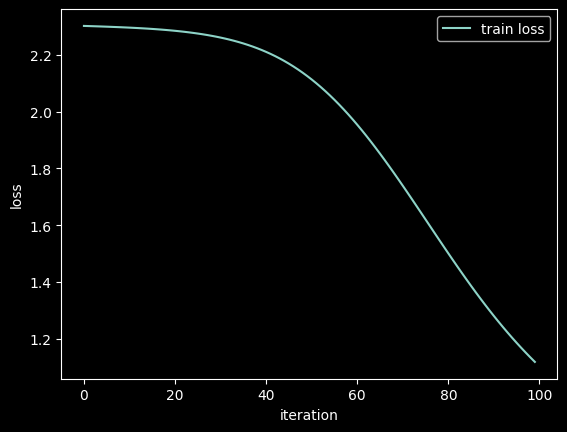

In [299]:
plt.plot(train_losses, label="train loss")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

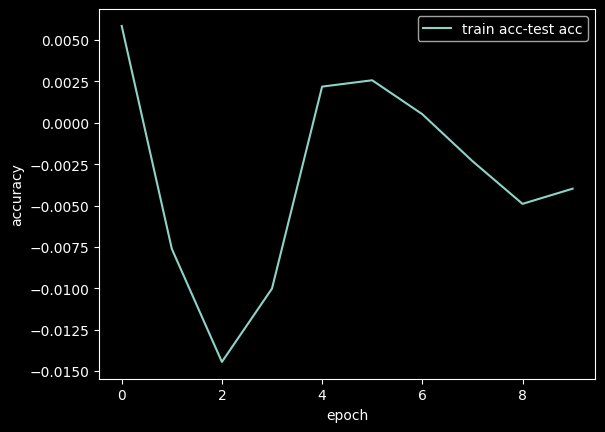

In [300]:
plt.plot((np.array(train_accs) - np.array(test_accs)), label="train acc-test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()